<a href="https://colab.research.google.com/github/gerdoc-unir/M1-ACT-1/blob/Analisis_Visual/Actividad1_MODAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from typing import AnyStr, List
import os
from pathlib import Path
import shutil
import random
import tensorflow as tf

from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
# Importando layers de keras
from tensorflow.keras import layers
import numpy as np


In [2]:
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
!rm -fr images

In [4]:
#Declaración de variables
path_img_tar: AnyStr = 'images.tar.gz'
path_annotations_tar: AnyStr = 'annotations.tar.gz'
path_img: AnyStr = 'images'
path_annotations: AnyStr = 'annotations'
cat_label: AnyStr = 'cat'
dog_label: AnyStr = 'dog'
train_label: AnyStr = 'train'
validation_label: AnyStr = 'validation'
test_label: AnyStr = 'test'
total_label: AnyStr = 'total'
conjunto_label: AnyStr = "Conjunto"
carpeta_img: Path = None
archivos: List = None
carpeta_train: Path = None
carpeta_validation: Path = None
carpeta_test: Path = None
archivos_gatos: List = None
archivos_perros: List = None
proporciones: List[float] = [0.8, 0.1, 0.1]
gatos_train:List = []
gatos_validation:List = []
gatos_test: List = []
perros_train:List = []
perros_validation:List = []
perros_test: List = []
IMG_HEIGHT = 160
IMG_WIDTH = 160
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32

In [5]:
#Validamos la separación sea correcta
assert abs(sum(proporciones) - 1.0) < 1e-9

In [6]:
#Descargando images
if not os.path.exists( path_img_tar ):
  print('Descargando imagenes...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_img_tar}')

#Descargando anotaciones
if not os.path.exists( path_annotations_tar ):
  print('Descargando anotaciones...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_annotations_tar}')

#Descompactando images
if os.path.exists( path_img_tar ) and not os.path.exists( path_img ):
  print('Descompactando imagenes...')
  os.system(f'tar -xf {path_img_tar}')
  carpeta_img: Path = Path( path_img )

#Descompactando anotaciones
if os.path.exists( path_annotations_tar ) and not os.path.exists( path_annotations ):
  print('Descompactando anotaciones...')
  os.system(f'tar -xf {path_annotations_tar}')


Descargando imagenes...
Descargando anotaciones...
Descompactando imagenes...
Descompactando anotaciones...


In [7]:
#Creación de carpetas
print('Creando carpetas de perros y gatos...')
if carpeta_img:
  archivos = list( carpeta_img.glob( "*.jpg" ) )
  print(f'Imagenes: {len(archivos)}' )
  carpeta_train = Path( f'{carpeta_img}/{train_label}' )
  carpeta_validation = Path( f'{carpeta_img}/{validation_label}' )
  carpeta_test = Path( f'{carpeta_img}/{test_label}' )
  carpetas: List[AnyStr] = [carpeta_train, carpeta_validation, carpeta_test]
  for carpeta in carpetas:
    if not os.path.exists( carpeta ):
      os.mkdir( carpeta )
      print( f'Creando {carpeta}' )
      os.mkdir( f'{carpeta}/{cat_label}' )
      print( f'Creando {carpeta}/{cat_label}' )
      os.mkdir( f'{carpeta}/{dog_label}' )
      print( f'Creando {carpeta}/{dog_label}' )

  if len( archivos ) > 0:
    archivos_gatos = []
    archivos_perros = []
    for archivo in archivos:
      if archivo.name[ 0 ].isupper( ):
        archivos_gatos.append( archivo )
      else:
        archivos_perros.append( archivo )
  if len( archivos_gatos ) > 0:
    print(f'Gatos: {len(archivos_gatos)}')
  if len( archivos_perros ) > 0:
    print(f'Perros: {len(archivos_perros)}')



Creando carpetas de perros y gatos...
Imagenes: 7390
Creando images/train
Creando images/train/cat
Creando images/train/dog
Creando images/validation
Creando images/validation/cat
Creando images/validation/dog
Creando images/test
Creando images/test/cat
Creando images/test/dog
Gatos: 2400
Perros: 4990


In [8]:
#Hacemos que se revuelvean los datos
random.seed( 42 )
random.shuffle( archivos_gatos )
random.shuffle( archivos_perros )

In [9]:
#Separamos los archivos en los distintos dataset
def dividir_archivos(archivos: List, proporciones: List[float]):
    total:int = len( archivos )
    limite_train:int = int(total * proporciones[0])
    limite_validation:int = limite_train + int(total * proporciones[1])
    train:List = archivos[:limite_train]
    validation: List = archivos[limite_train:limite_validation]
    test: List = archivos[limite_validation:]
    return train, validation, test

In [10]:
#Dataset de los archivos
gatos_train, gatos_validation, gatos_test = dividir_archivos( archivos_gatos, proporciones )
perros_train, perros_validation, perros_test = dividir_archivos( archivos_perros, proporciones )

In [11]:
#Movemos los archivos a las carpetas de los dataset
def mover_archivos(archivos:List, destino: AnyStr):
    for i, archivo in enumerate(archivos):
      nueva_ruta = Path( f'{destino}/{archivo.name}' )
      shutil.move( archivo, nueva_ruta )
      archivos[ i ] = nueva_ruta


def obtener_raza(archivo: Path) -> str:
    return archivo.stem.rsplit("_", 1)[0]


In [12]:
#movemos los archivos a la estructura de la carpeta
mover_archivos( gatos_train, f'{carpeta_train}/{cat_label}' )
mover_archivos( perros_train, f'{carpeta_train}/{dog_label}')
mover_archivos( gatos_validation, f'{carpeta_validation}/{cat_label}')
mover_archivos( perros_validation, f'{carpeta_validation}/{dog_label}' )
mover_archivos( gatos_test, f'{carpeta_test}/{cat_label}' )
mover_archivos( perros_test, f'{carpeta_test}/{dog_label}' )

## Análisis exploratorio de los datos utilizados


In [13]:
datos: List[ object ] = [
    {conjunto_label: train_label,cat_label: len(gatos_train), dog_label: len(perros_train), total_label: len(gatos_train) + len(perros_train)},
    {conjunto_label: validation_label,cat_label: len(gatos_validation), dog_label: len(perros_validation),total_label: len(gatos_validation) + len(perros_validation)},
    {conjunto_label: test_label,cat_label: len(gatos_test), dog_label: len(perros_test),total_label: len(gatos_test) + len(perros_test)}
    ]
df = pd.DataFrame( datos )
total = pd.DataFrame( [{conjunto_label:total_label, cat_label:df[cat_label].sum(),dog_label:df[dog_label].sum(),total_label:df[total_label].sum()}])
df = pd.concat( [df, total], ignore_index=True )
df.style.format({
    cat_label: "{:,}",
    dog_label: "{:,}",
    total_label: "{:,}"
})


,Conjunto,cat,dog,total
0,train,"1,920","3,992","5,912"
1,validation,240,499,739
2,test,240,499,739
3,total,"2,400","4,990","7,390"


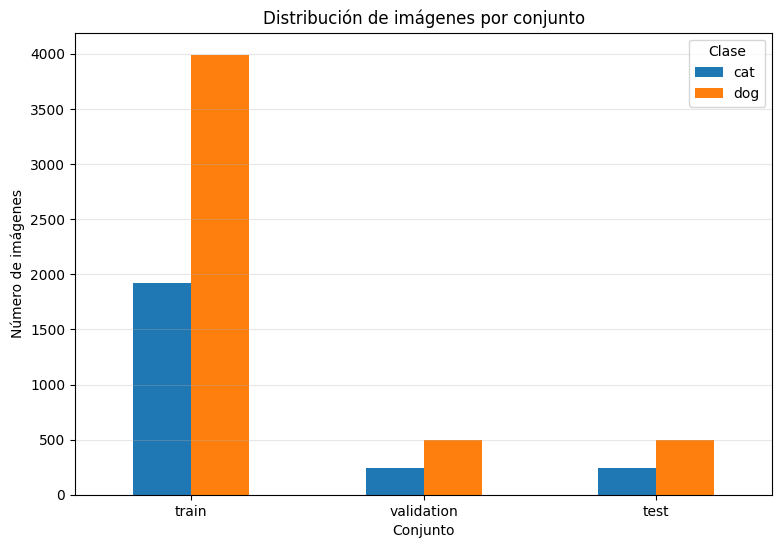

In [14]:
df_grafica = df[df[conjunto_label] != total_label]
df_grafica.plot( x=conjunto_label, y=[cat_label, dog_label], kind="bar", figsize=(9, 6), title="Distribución de imágenes por conjunto")
plt.xlabel( conjunto_label )
plt.ylabel("Número de imágenes")
plt.xticks(rotation=0)
plt.legend( title="Clase" )
plt.grid(axis="y", alpha=0.3)
plt.show()

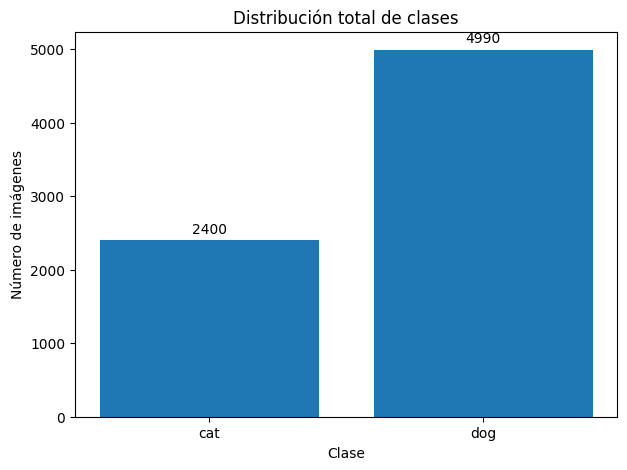

In [15]:
totales = df[ df[ conjunto_label] == total_label]
valores = [ totales[ cat_label ].iloc[0], totales[ dog_label ].iloc[0] ]
plt.figure(figsize=(7, 5))
barras = plt.bar( [ cat_label, dog_label ], valores )
plt.title("Distribución total de clases")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.bar_label( barras, fmt="%d",padding=3 )
plt.show()

In [16]:
gatos: int = total[ cat_label ].iloc[ 0 ]
perros: int = total[ dog_label ].iloc[ 0 ]
imagenes:int  = total[ total_label ].iloc[ 0 ]
porcentaje_gatos: float = gatos / imagenes * 100
porcentaje_perros: float = perros / imagenes * 100
print(f"Total de imágenes: {imagenes:,}")
print(f"Gatos: {gatos:,} ({porcentaje_gatos:.2f}%)")
print(f"Perros: {perros:,} ({porcentaje_perros:.2f}%)")
mayor = max(gatos, perros)
menor = min(gatos, perros)
ratio = mayor / menor
print(f"Relación de desbalance: {ratio:.2f}:1")

Total de imágenes: 7,390
Gatos: 2,400 (32.48%)
Perros: 4,990 (67.52%)
Relación de desbalance: 2.08:1


In [17]:
#Cargamos a keras el dataset
train_ds = keras.utils.image_dataset_from_directory( carpeta_train, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
validation_ds = keras.utils.image_dataset_from_directory( carpeta_validation, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
test_ds = keras.utils.image_dataset_from_directory( carpeta_test, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
print( train_ds.class_names )

Found 5912 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
['cat', 'dog']


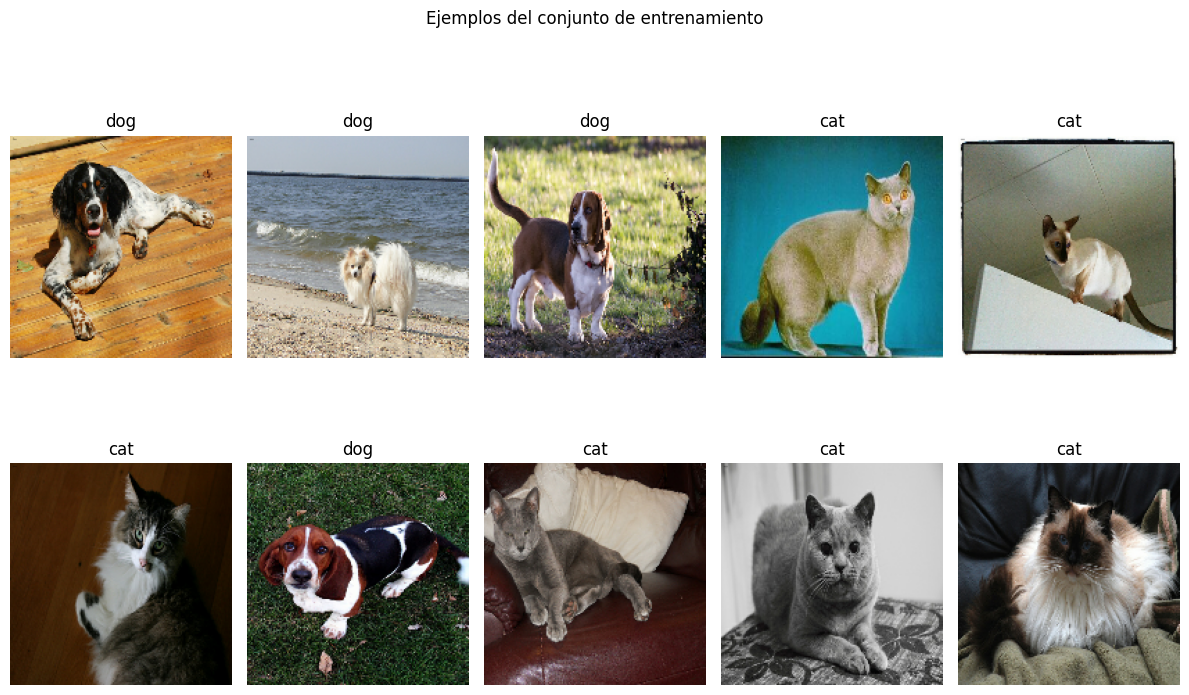

In [18]:
plt.figure(figsize=(12, 8))
for imagenes, etiquetas in train_ds.take(1):
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow( imagenes[ i ].numpy( ).astype( "uint8" ) )
        etiqueta = int( etiquetas[ i ].numpy( )[ 0 ])
        plt.title( train_ds.class_names[ etiqueta ] )
        plt.axis("off")
plt.suptitle("Ejemplos del conjunto de entrenamiento")
plt.tight_layout( )
plt.show( )

In [19]:
#Verificamos el tamaño de las imágenes
for imagenes, etiquetas in train_ds.take( 1 ):
    print( "Imágenes:", imagenes.shape)
    print( "Etiquetas:", etiquetas.shape)

Imágenes: (32, 160, 160, 3)
Etiquetas: (32, 1)


## **Conclusiones**
El dataset está compuesto por un total de **7,390 imágenes**, distribuidas en dos clases:

- **Gatos:** 2,400 imágenes (**32.48 %**).
- **Perros:** 4,990 imágenes (**67.52 %**).

Las imágenes fueron divididas en tres conjuntos utilizando una proporción de **80 % para entrenamiento, 10 % para validación y 10 % para prueba**:
Se identificó un **desbalance entre las clases**, debido a que aproximadamente el **67.52 %** de las imágenes corresponden a perros y el **32.48 %** a gatos. Esto representa una relación aproximada de **2.08 imágenes de perros por cada imagen de gato**.

La inspección visual de ejemplos del conjunto de entrenamiento permitió observar imágenes con diferentes razas, tamaños, posiciones, fondos e iluminación. Esta diversidad representa un reto para el modelo, ya que deberá aprender características que permitan diferenciar gatos y perros bajo diferentes condiciones.


## **Modelo uno**

In [65]:
normalizacion = layers.Rescaling(1.0/ 255)
train_ds = train_ds.map(lambda x, y: (normalizacion(x), y))
validation_ds = validation_ds.map(lambda x, y: (normalizacion(x), y))

# Mejora de rendimiento
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)

# Creación de Modelo
input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)
alpha=0.1
modelo = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512),
    layers.LeakyReLU(alpha=alpha),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [66]:
# Comienza entrenamiento de LeakyReLU
modelo.summary()

history_m1 = modelo.fit(train_ds, validation_data=validation_ds, epochs=25)

print( history_m1.history.keys())

print("Accuracy final entrenamiento:",
      history_m1.history["accuracy"][-1])

print("Accuracy final validación:",
      history_m1.history["val_accuracy"][-1])

print("Loss final entrenamiento:",
      history_m1.history["loss"][-1])

print("Loss final validación:",
      history_m1.history["val_loss"][-1])


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,795,457 (25.92 MB)

 Trainable params: 6,795,457 (25.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.6735 - loss: 0.6377 - val_accuracy: 0.6752 - val_loss: 0.6333
Epoch 2/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6752 - loss: 0.6357 - val_accuracy: 0.6752 - val_loss: 0.6316
Epoch 3/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6752 - loss: 0.6356 - val_accuracy: 0.6752 - val_loss: 0.6304
Epoch 4/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6752 - loss: 0.6324 - val_accuracy: 0.6752 - val_loss: 0.6339
Epoch 5/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6752 - loss: 0.6343 - val_accuracy: 0.6752 - val_loss: 0.6304
Epoch 6/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6752 - loss: 0.6362 - val_accuracy: 0.6752 - val_loss: 0.6329
Epoch 7/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6752 - loss: 0.6323 - val_accuracy: 0.6752 - val_loss: 0.6322
Epoch 8/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6752 - loss: 0.6329 - val_acc

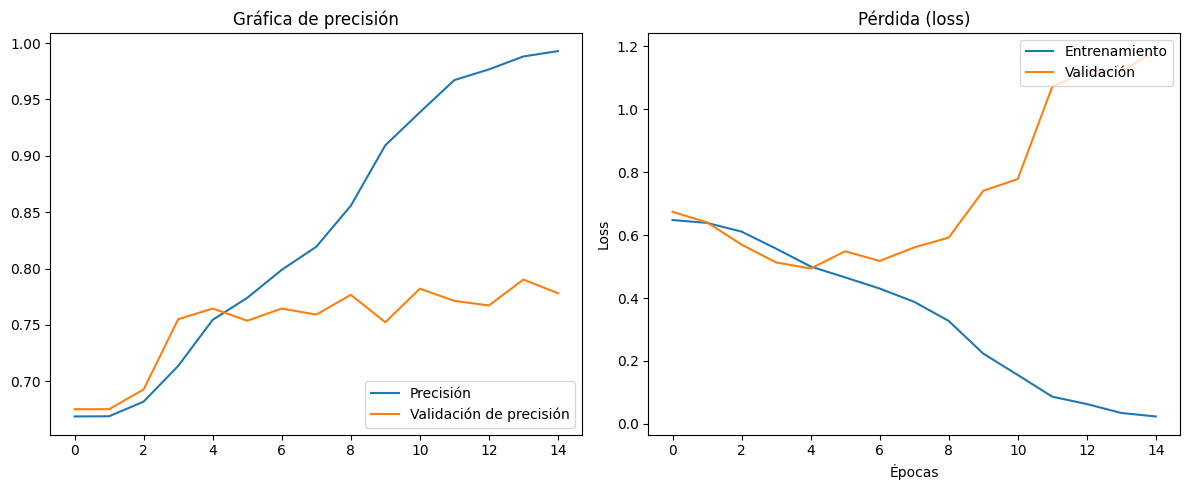

In [67]:
# Se procede a la graficación de los resultados

acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history["loss"]
val_loss = historial.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Gráfica de precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Precisión")
plt.plot(epochs_range, val_acc, label="Validación de precisión")
plt.legend(loc="lower right")
plt.title("Gráfica de precisión")

# Gráfica de pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Entrenamiento")
plt.plot(epochs_range, val_loss, label="Validación")
plt.legend(loc="upper right")
plt.title("Pérdida (loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

**Análisis de resultados modelo 1**

## Modelo 2 con Batch Normalizaton y Dropout

In [23]:
modelo_relu_bn_dropout = keras.Sequential([
    layers.Input(shape=(160,160,3)),

    layers.Conv2D(32, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(2, activation="softmax")
], name="modelo_relu_bn_dropout")

In [24]:
modelo_relu_bn_dropout.summary()

Model: "modelo_relu_bn_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,490 (1.62 MB)

 Trainable params: 422,530 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [25]:
modelo_relu_bn_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
early_stopping_bn = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [27]:
history_relu_bn_dropout = modelo_relu_bn_dropout.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=[early_stopping_bn]
)

Epoch 1/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.6666 - loss: 0.6467 - val_accuracy: 0.6509 - val_loss: 0.6622
Epoch 2/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6817 - loss: 0.5962 - val_accuracy: 0.6915 - val_loss: 0.6338
Epoch 3/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6891 - loss: 0.5898 - val_accuracy: 0.6820 - val_loss: 0.5931
Epoch 4/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6937 - loss: 0.5869 - val_accuracy: 0.6834 - val_loss: 0.6195
Epoch 5/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6982 - loss: 0.5724 - val_accuracy: 0.6955 - val_loss: 0.6010
Epoch 6/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7035 - loss: 0.5693 - val_accuracy: 0.5900 - val_loss: 0.6658
Epoch 7/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7109 - loss: 0.5634 - val_accuracy: 0.6806 - val_loss: 0.5996
Epoch 8/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7194 - loss: 0.5495 - val_acc

In [28]:
test_ds_eval = keras.utils.image_dataset_from_directory(
    carpeta_test,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 739 files belonging to 2 classes.


In [29]:
resultado_test_bn = modelo_relu_bn_dropout.evaluate(test_ds_eval)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6874 - loss: 62.1325 


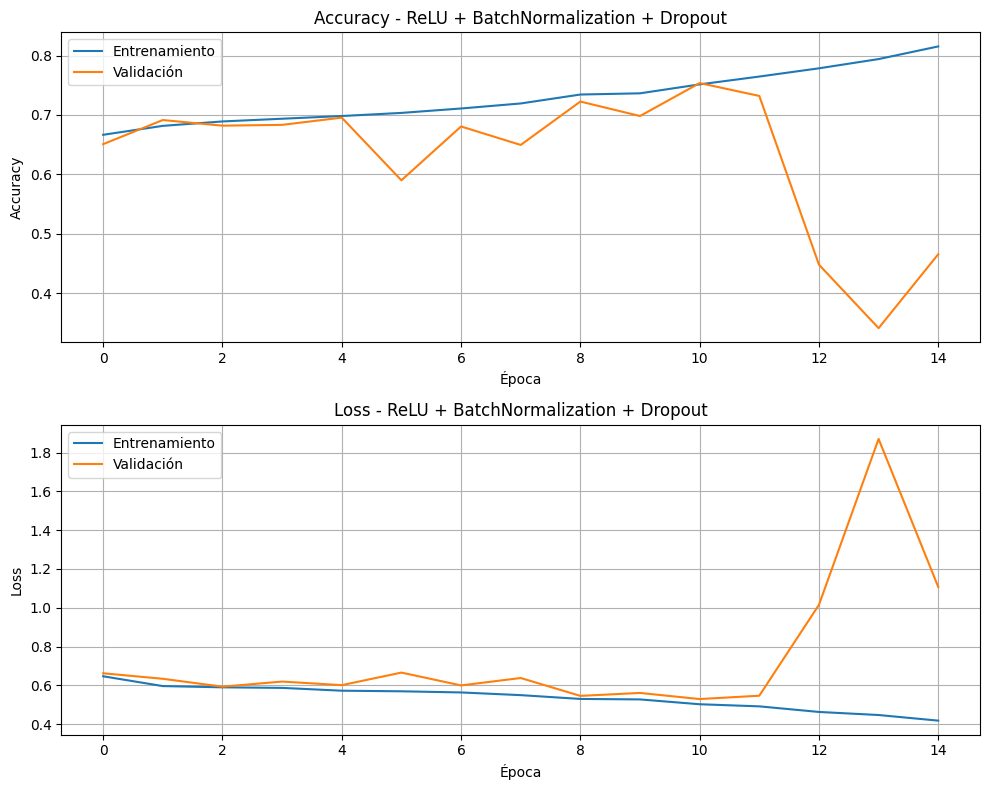

In [30]:
plt.figure(figsize=(10, 8))

# Accuracy
plt.subplot(2, 1, 1)
plt.plot(history_relu_bn_dropout.history["accuracy"], label="Entrenamiento")
plt.plot(history_relu_bn_dropout.history["val_accuracy"], label="Validación")
plt.title("Accuracy - ReLU + BatchNormalization + Dropout")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(2, 1, 2)
plt.plot(history_relu_bn_dropout.history["loss"], label="Entrenamiento")
plt.plot(history_relu_bn_dropout.history["val_loss"], label="Validación")
plt.title("Loss - ReLU + BatchNormalization + Dropout")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Análisis de resultados modelo 2**

Se obtuvo un **accuracy de 68.74% en el conjunto de prueba**. Durante el entrenamiento el modelo inició con un accuracy de **95.20%** y alcanzo un **accuracy de validación de 89.04%** en el octavo Epoch. Esto utilizando una CNN con **ReLU,BatchNormalization y Dropout**.

## Modelo 3

In [31]:
# ------ concluye código base

#comenzamos con la normalización
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
])

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

x = keras.layers.Rescaling(1./255)(inputs)
#x = data_augmentation(x)


#se extraen las características
x = keras.layers.Conv2D(32, 3, activation='relu')(x)
x = keras.layers.MaxPooling2D()(x)
x = keras.layers.Conv2D(64, 3, activation='relu')(x)
x = keras.layers.MaxPooling2D()(x)
x = keras.layers.Conv2D(128, 3, activation='relu')(x)
x = keras.layers.MaxPooling2D()(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.5)(x)

#se le da salida
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

#ahora compilamos
model.compile(
    optimizer='adam',
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

model.summary()

#entrenamiento
epochs = 25
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs
)

#ejecución de la precisión
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nPrecisión en Test: {test_acc:.4f}")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     2,654,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,747,585 (10.48 MB)

 Trainable params: 2,747,585 (10.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.6742 - loss: 0.6433 - val_accuracy: 0.6752 - val_loss: 0.6332
Epoch 2/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6752 - loss: 0.6340 - val_accuracy: 0.6752 - val_loss: 0.6417
Epoch 3/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6752 - loss: 0.6369 - val_accuracy: 0.6752 - val_loss: 0.6350
Epoch 4/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6752 - loss: 0.6368 - val_accuracy: 0.6752 - val_loss: 0.6310
Epoch 5/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6752 - loss: 0.6358 - val_accuracy: 0.6752 - val_loss: 0.6319
Epoch 6/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6752 - loss: 0.6342 - val_accuracy: 0.6752 - val_loss: 0.6312
Epoch 7/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6752 - loss: 0.6359 - val_accuracy: 0.6752 - val_loss: 0.6308
Epoch 8/25
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6752 - loss: 0.6355 - val_acc

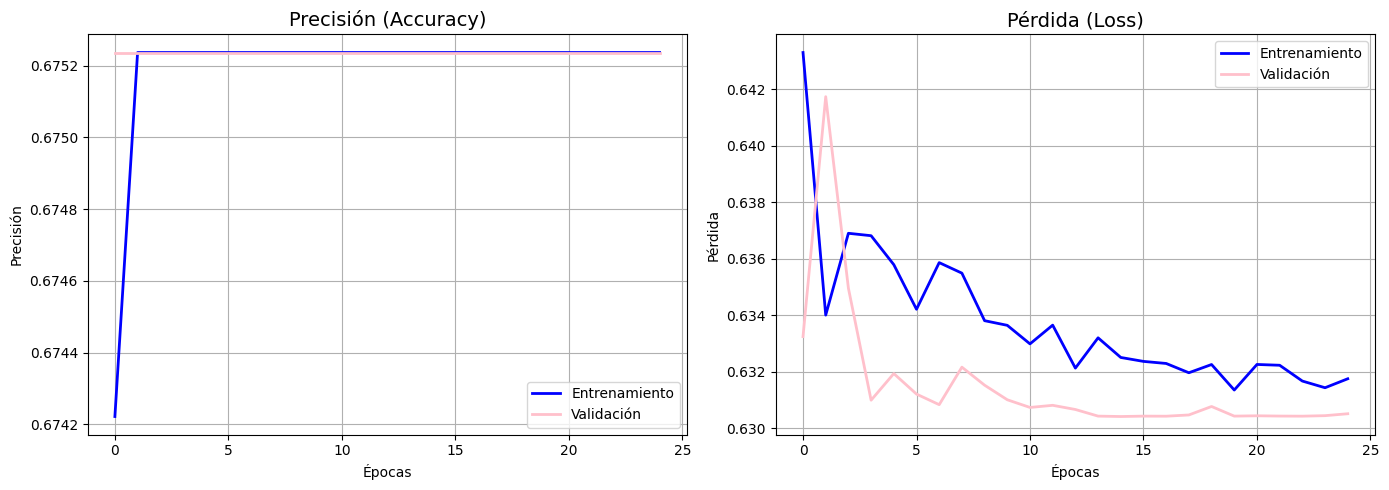

In [32]:
#ahora graficamos
import matplotlib.pyplot as plt

# Extraer los datos del historial de entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Configurar el tamaño de la figura
plt.figure(figsize=(14, 5))

# Gráfica 1: Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validación', color='pink', linewidth=2)
plt.title('Precisión (Accuracy)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True)

# Gráfica 2: Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validación', color='pink', linewidth=2)
plt.title('Pérdida (Loss)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True)

# Mostrar gráficas
plt.tight_layout()
plt.show()



**Análisis de resultados modelo 3**

Tenemos una precisión del **83.36%**, iniciando el entrenamiento con una precisión del 66.96, incrementando en 10 epoch que se realizaron, esto utilizando el modelo **sigmoid**

## Modelo 4

In [33]:
# Normalización de pixeles [0,255] -> [0,1]
normalizacion = layers.Rescaling(1.0 / 255)
train_ds = train_ds.map(lambda x, y: (normalizacion(x), y))
validation_ds = validation_ds.map(lambda x, y: (normalizacion(x), y))

# Prefetch para mejorar rendimiento
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)


In [34]:
# Creación de modelo TANH
input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)
alpha = 0.1
modeloTANH = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation="tanh"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

modeloTANH.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [35]:
# Entrenar tanh
modeloTANH.summary()

historial = modeloTANH.fit(train_ds, validation_data=validation_ds, epochs=15)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,795,457 (25.92 MB)

 Trainable params: 6,795,457 (25.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.6688 - loss: 0.6479 - val_accuracy: 0.6752 - val_loss: 0.6740
Epoch 2/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6690 - loss: 0.6387 - val_accuracy: 0.6752 - val_loss: 0.6404
Epoch 3/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6820 - loss: 0.6110 - val_accuracy: 0.6928 - val_loss: 0.5696
Epoch 4/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7136 - loss: 0.5569 - val_accuracy: 0.7551 - val_loss: 0.5130
Epoch 5/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7546 - loss: 0.5002 - val_accuracy: 0.7645 - val_loss: 0.4937
Epoch 6/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7740 - loss: 0.4656 - val_accuracy: 0.7537 - val_loss: 0.5485
Epoch 7/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7989 - loss: 0.4301 - val_accuracy: 0.7645 - val_loss: 0.5178
Epoch 8/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8194 - loss: 0.3879 - val_acc

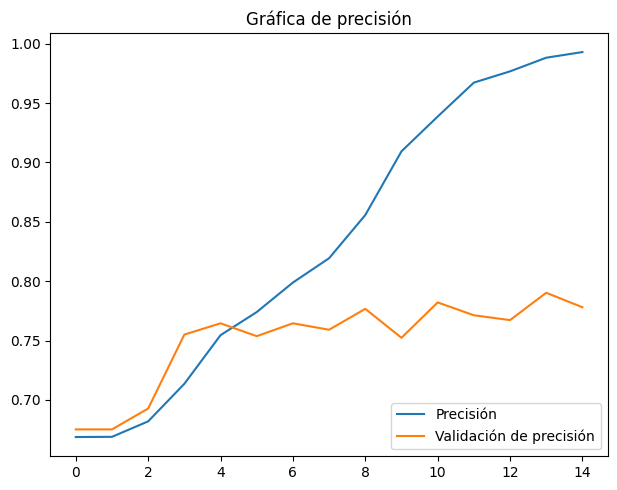

In [36]:
# Graficar resultados
acc = historial.history["accuracy"]
val_acc = historial.history["val_accuracy"]
loss = historial.history["loss"]
val_loss = historial.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Gráfica de precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Precisión")
plt.plot(epochs_range, val_acc, label="Validación de precisión")
plt.legend(loc="lower right")
plt.title("Gráfica de precisión")

plt.tight_layout()
plt.show()


**Análisis de resultados modelo 4**

## **Análisis visual de los errores del modelo**

In [68]:
y_real = []
y_pred = []
imagenes_error = []
probabilidades_error = []

for imagenes, etiquetas in test_ds:

    probabilidades = model.predict(imagenes, verbose=0).flatten()
    predicciones = (probabilidades >= 0.5).astype(int)

    for imagen, real, pred, prob in zip(imagenes, etiquetas.numpy().flatten(),predicciones,probabilidades):
        real = int(real)
        y_real.append(real)
        y_pred.append(pred)
        if real != pred:
            imagenes_error.append(imagen)
            probabilidades_error.append(prob)

In [69]:
errores = np.array(y_real) != np.array(y_pred)

print(f"Imágenes evaluadas: {len(y_real)}")
print(f"Errores: {errores.sum()}")
print(f"Aciertos: {(~errores).sum()}")
print(f"Porcentaje de error: {errores.mean() * 100:.2f}%")

Imágenes evaluadas: 739
Errores: 240
Aciertos: 499
Porcentaje de error: 32.48%


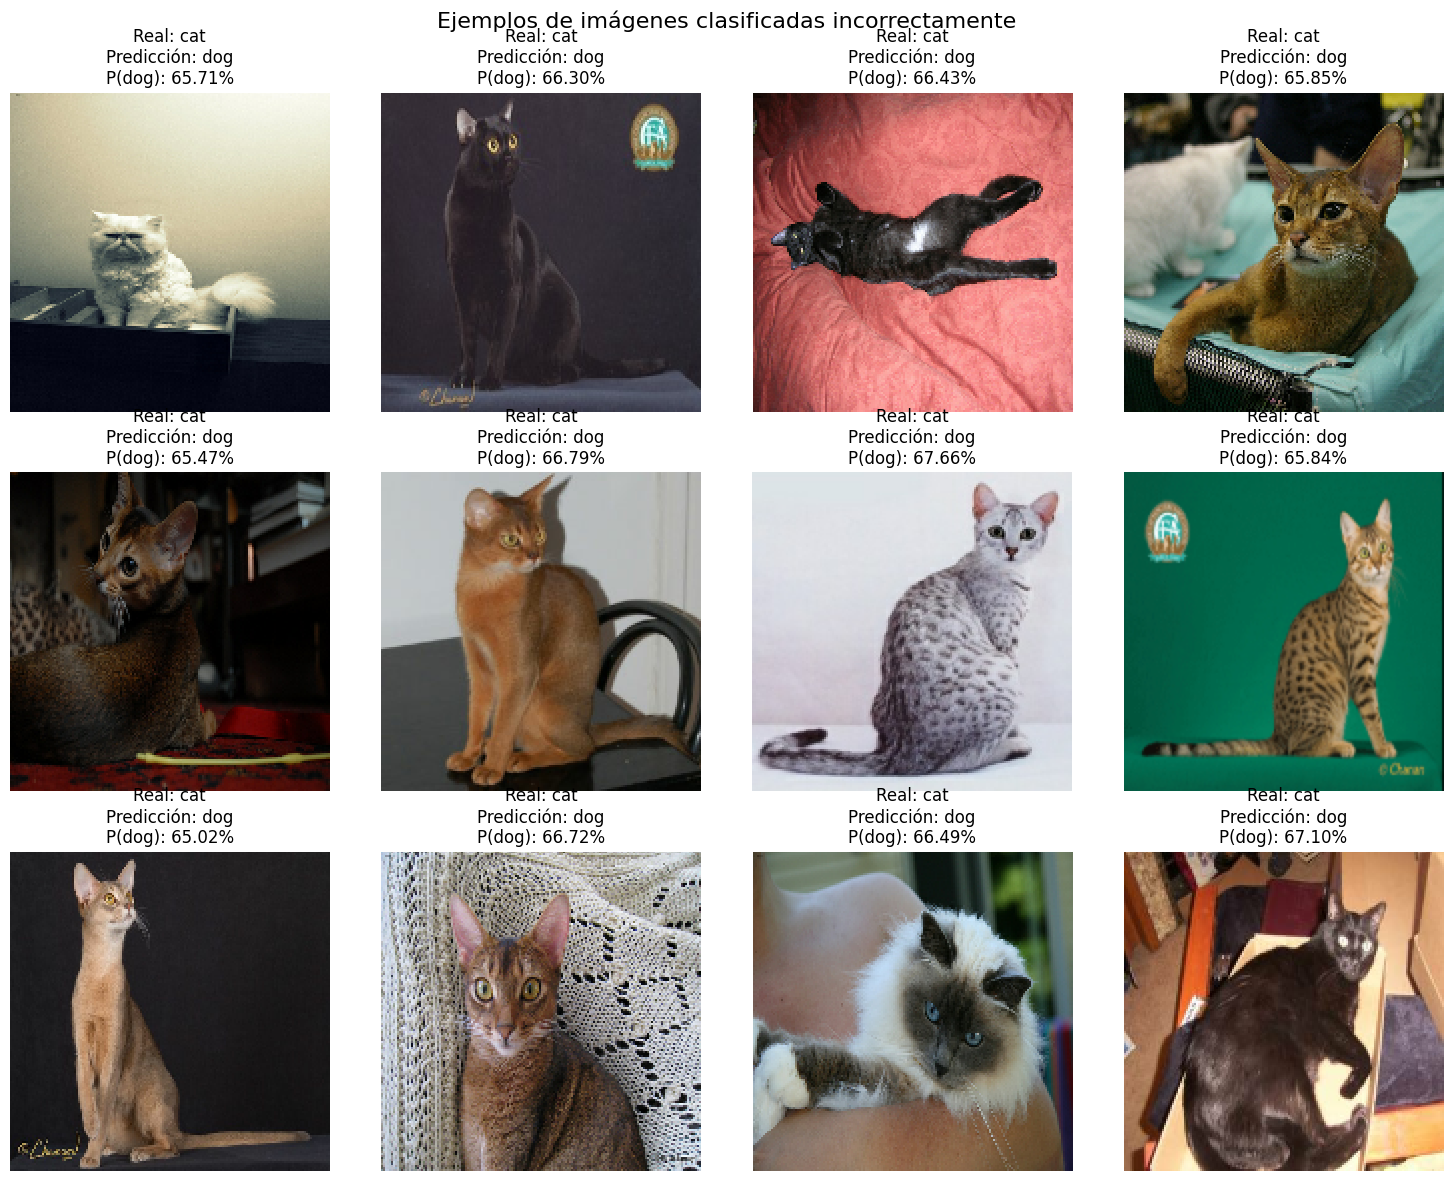

In [70]:
class_names = test_ds.class_names
plt.figure(figsize=(15, 12))
cantidad = min(12, len(imagenes_error))
for i in range(cantidad):
    ax = plt.subplot(3, 4, i + 1)
    imagen = imagenes_error[i].numpy().astype("uint8")
    prob = probabilidades_error[i]
    pred = 1 if prob >= 0.5 else 0
    real = 1 - pred
    plt.imshow(imagen)
    plt.title(
        f"Real: {class_names[real]}\n"
        f"Predicción: {class_names[pred]}\n"
        f"P(dog): {prob:.2%}"
    )
    plt.axis("off")
plt.suptitle(
    "Ejemplos de imágenes clasificadas incorrectamente",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [71]:
gatos_como_perros = 0
perros_como_gatos = 0

for real, pred in zip(y_real, y_pred):
    if real == 0 and pred == 1:
        gatos_como_perros += 1

    elif real == 1 and pred == 0:
        perros_como_gatos += 1
print("Gatos clasificados como perros:",gatos_como_perros)
print("Perros clasificados como gatos:",perros_como_gatos)

Gatos clasificados como perros: 240
Perros clasificados como gatos: 0


In [72]:
datos_test = []
for archivo in gatos_test + perros_test:
    datos_test.append({
        "archivo": archivo.name,
        "raza": obtener_raza(archivo),
        "ruta": archivo,
        "clase": archivo.parent.name,
        "real": archivo.parent.name
    })

df_test = pd.DataFrame(datos_test)

In [73]:
predicciones = []
probabilidades = []

for ruta in df_test["ruta"]:
    imagen = keras.utils.load_img(ruta,target_size=IMG_SIZE)
    imagen = keras.utils.img_to_array(imagen)
    imagen = imagen / 255.0
    imagen = np.expand_dims(imagen, axis=0)

    probabilidad = model.predict(
        imagen,
        verbose=0
    )[0][0]

    prediccion = (
        dog_label
        if probabilidad >= 0.5
        else cat_label
    )

    probabilidades.append(float(probabilidad))
    predicciones.append(prediccion)
df_test["prediccion"] = predicciones
df_test["probabilidad"] = probabilidades

df_test["correcto"] = (df_test["real"] ==df_test["prediccion"])

In [74]:
df_test["prediccion"].value_counts()



,count
prediccion,
dog,739


In [75]:
df_test["probabilidad"].describe()

,probabilidad
count,739.00000
mean,0.66863
std,0.00000
min,0.66863
25%,0.66863
50%,0.66863
75%,0.66863
max,0.66863


In [76]:
pd.crosstab(
    df_test["real"],
    df_test["prediccion"],
    margins=True
)

prediccion,dog,All
real,,
cat,240,240
dog,499,499
All,739,739


In [77]:
modelo.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,386,373 (77.77 MB)

 Trainable params: 6,795,457 (25.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,590,916 (51.85 MB)

In [78]:
analisis_clase = ( df_test.groupby("real")
    .agg(
        imagenes=("correcto", "size"),
        aciertos=("correcto", "sum")
    )
)

analisis_clase["errores"] = (
    analisis_clase["imagenes"] -
    analisis_clase["aciertos"]
)

analisis_clase["porcentaje_error"] = (
    analisis_clase["errores"] /
    analisis_clase["imagenes"] *
    100
)

analisis_clase

,imagenes,aciertos,errores,porcentaje_error
real,,,,
cat,240,0,240,100.0
dog,499,499,0,0.0


Clase más problemática: cat


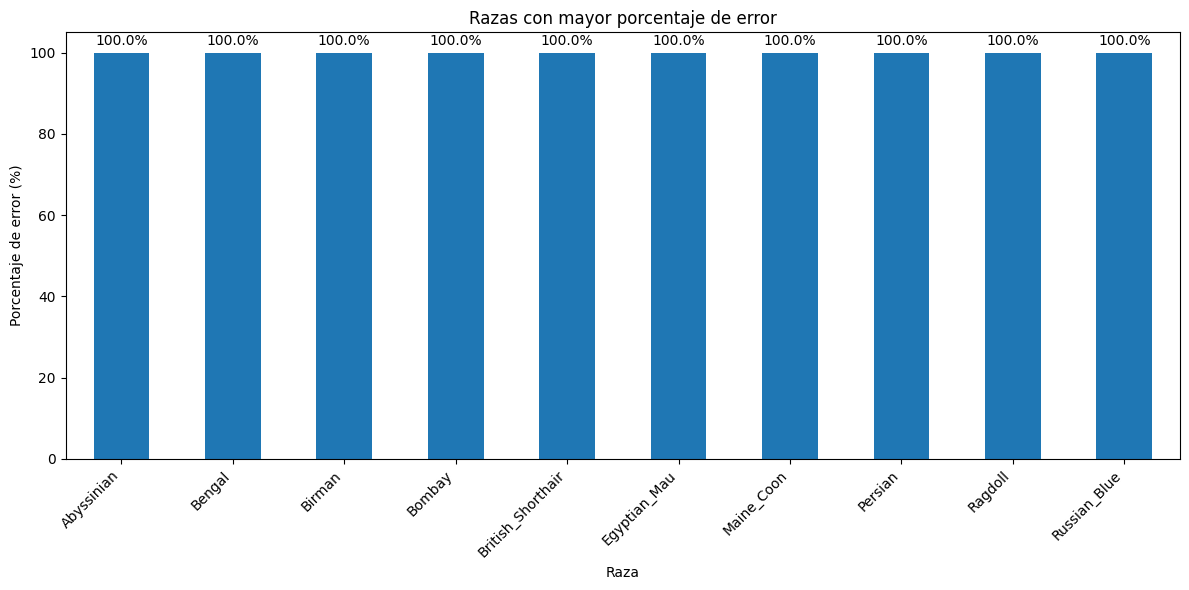

In [79]:
clase_problematica = ( analisis_clase["porcentaje_error"].idxmax( ) )
print("Clase más problemática:",clase_problematica )

analisis_raza = (df_test
    .groupby(["real", "raza"])
    .agg(
        imagenes=("correcto", "size"),
        aciertos=("correcto", "sum")
    )
)
analisis_raza["errores"] = (analisis_raza["imagenes"] -analisis_raza["aciertos"] )
analisis_raza["porcentaje_error"] = (analisis_raza["errores"] /analisis_raza["imagenes"] *100)
analisis_raza = analisis_raza.sort_values("porcentaje_error",ascending=False)
top_10 = analisis_raza.head(10).reset_index()

ax = top_10.plot(
    x="raza",
    y="porcentaje_error",
    kind="bar",
    figsize=(12, 6),
    legend=False
)

plt.title("Razas con mayor porcentaje de error")
plt.xlabel("Raza")
plt.ylabel("Porcentaje de error (%)")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

Total de errores: 240


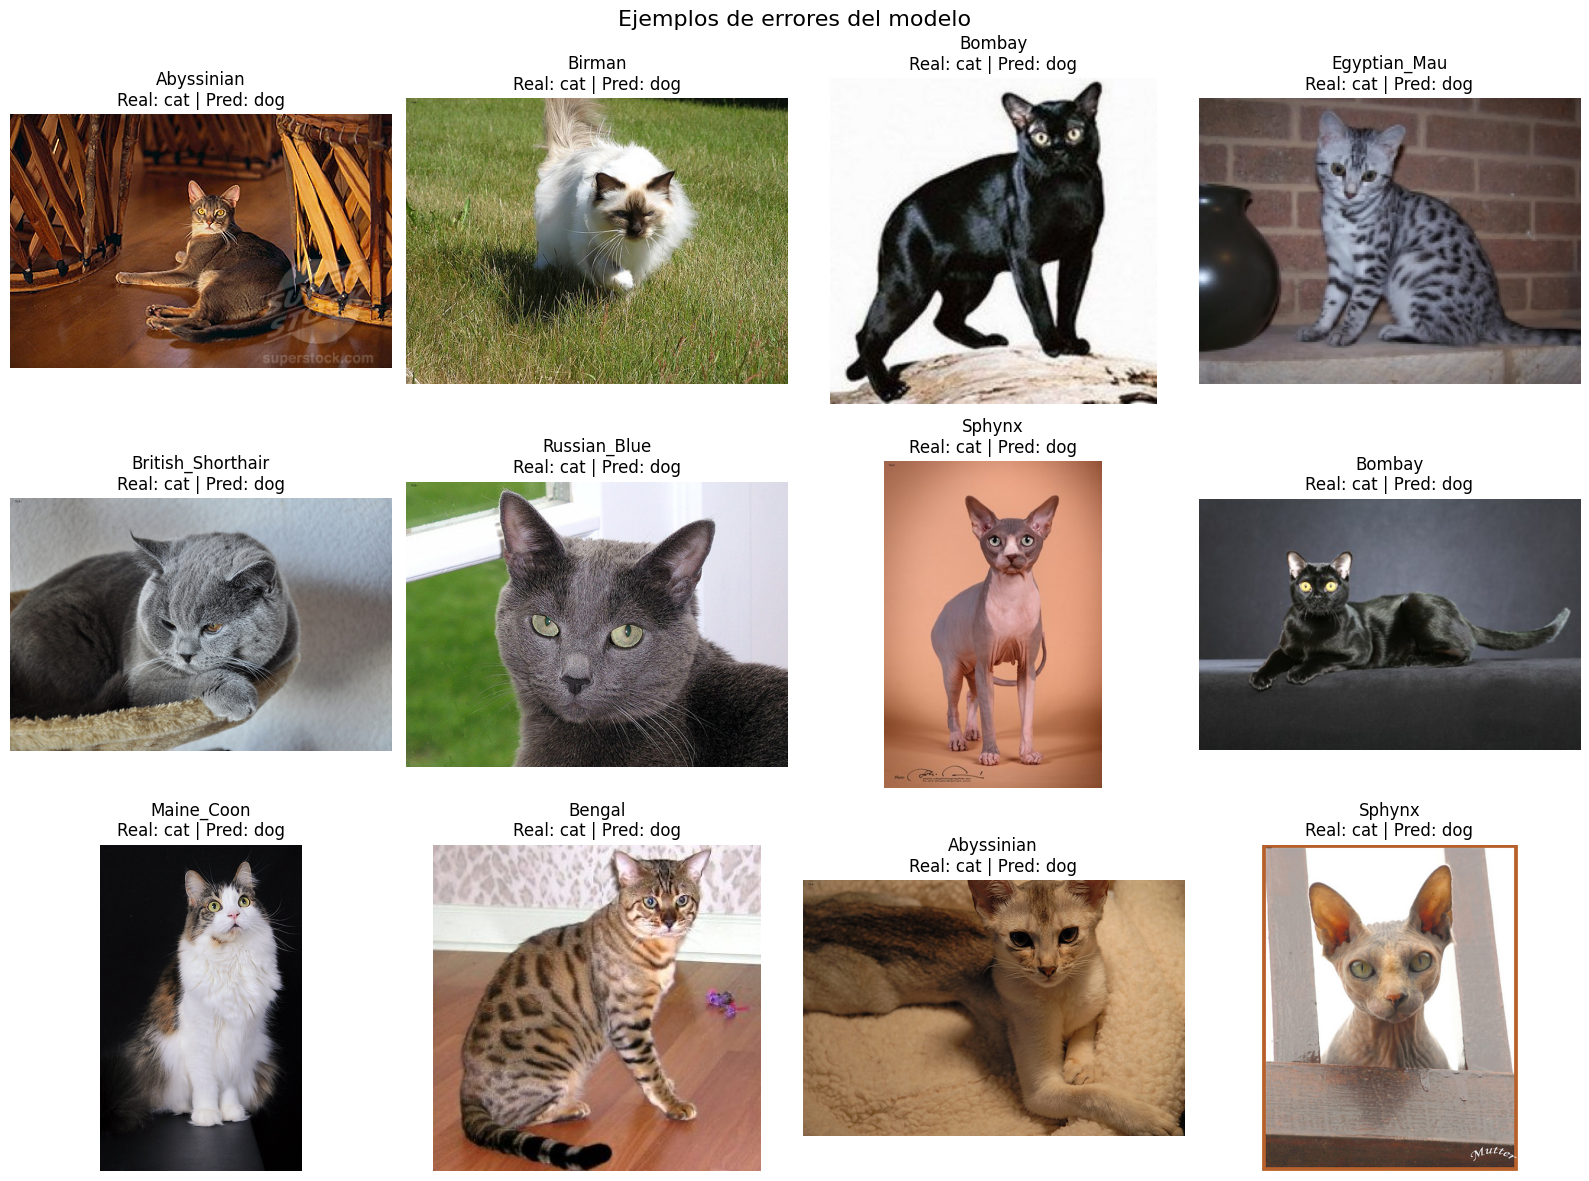

In [80]:
df_errores = df_test[df_test["correcto"] == False].copy()
print("Total de errores:", len(df_errores))
muestra = df_errores.head(12)
plt.figure(figsize=(16, 12))
for i, (_, fila) in enumerate( muestra.iterrows( ) ):
    imagen = keras.utils.load_img(fila["ruta"])
    plt.subplot(3, 4, i + 1)
    plt.imshow(imagen)
    plt.title(
        f"{fila['raza']}\n"
        f"Real: {fila['real']} | "
        f"Pred: {fila['prediccion']}"
    )
    plt.axis("off")
plt.suptitle("Ejemplos de errores del modelo",fontsize=16)
plt.tight_layout()
plt.show()